In [30]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# make matplotlib render svg
%config InlineBackend.figure_format = 'svg'

import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.mgf_dataset import create_mgf_dataset
from src.mgf_dataset import simulate_ou_process
from src.model import SimpleTransformer

# Compute likelihood of test theta values based on training distribution
from scipy.stats import lognorm
import numpy as np


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import pandas as pd

results_path = "../experiments/345345_predictive_test_results.csv"
results_df = pd.read_csv(results_path)


In [32]:
lengths = results_df.sequence_length.unique()
lengths
results_df

,sweep_name,sequence_length,theta,trained_squared_bias,trained_variance,trained_relative_error,untrained_squared_bias,untrained_variance,untrained_relative_error,num_replicates
0,theta_sweeps,5,0.1000,0.004805,9.714609,9.719414,1.937585,10403.584961,10405.522546,5000
1,theta_sweeps,5,0.2625,0.014665,1.188530,1.203194,0.814838,895.088074,895.902912,5000
2,theta_sweeps,5,0.4250,0.002606,295.093964,295.096570,3.653235,142386.250000,142389.903235,5000
3,theta_sweeps,5,0.5875,0.009054,8.837714,8.846768,0.519075,3255.638916,3256.157991,5000
4,theta_sweeps,5,0.7500,0.002929,0.582303,0.585233,0.025255,299.231689,299.256944,5000
...,...,...,...,...,...,...,...,...,...,...
220,theta_sweeps,400,3.3500,5.634538,6895.214844,6900.849382,45.511100,164518.343750,164563.854850,5000
221,theta_sweeps,400,3.5125,2.876924,1952.313599,1955.190523,11.352209,50564.910156,50576.262365,5000
222,theta_sweeps,400,3.6750,1.553476,206.080048,207.633523,0.944522,5195.336914,5196.281436,5000
223,theta_sweeps,400,3.8375,0.724599,28981.021484,28981.746083,0.750618,694015.562500,694016.313118,5000


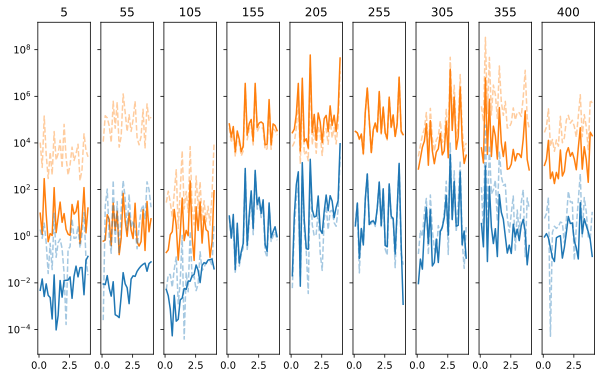

In [33]:


fig,axs = plt.subplots(figsize=(10,6),ncols = len(lengths), sharey=True)

for length in lengths:
    ax = axs[lengths==length][0]
    ax.set_title(f"{length}")
    df = results_df[results_df.sequence_length == length]
    bias = df.trained_squared_bias
    variance = df.trained_variance
    ut_bias = df.untrained_squared_bias
    ut_variance = df.untrained_variance
    theta = df.theta.to_numpy()
    ax.plot(theta, bias,"C0", label="squared bias")
    ax.semilogy(theta, variance , "C1", label="variance")
    ax.plot(theta, ut_bias,"C0--", label="untrained squared bias",alpha=0.4)
    ax.plot(theta, ut_variance, "C1--", label="untrained variance",alpha=0.4)

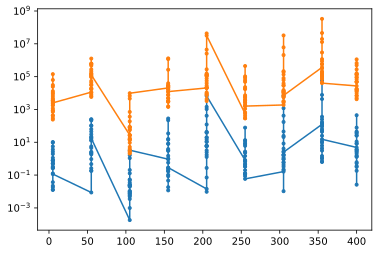

In [29]:
df = results_df[results_df.theta == results_df.theta.unique()[9]]
df = results_df #[results_df.theta == results_df.theta.unique()[9]]
bias = df.trained_squared_bias
variance = df.trained_variance
ut_bias = df.untrained_squared_bias
ut_variance = df.untrained_variance
lengths = df.sequence_length.to_numpy()

fig,ax = plt.subplots(figsize=(6,4))
ax.plot(lengths,  np.abs(bias - ut_bias), "C0.-",label="squared bias")
ax.semilogy(lengths, np.abs(variance - ut_variance), "C1.-",label="variance")

#ax.plot(lengths, ut_bias, "C0+--",label="untrained squared bias")
#ax.semilogy(lengths, ut_variance, "C1+--",label="untrained variance")